# Cake or Dog — interactive notebook

This notebook is intended for interactive work with the Cake-or-Dog classifier.

Main goals:
- model training and evaluation
- error visualization
- interactive predictions

## 0. Setup

Make sure that Jupyter is running in the same venv as the project.

In [1]:
# !pip install -e .

import sys
print(sys.executable)

/home/homka/code/ML/Cakeordog/.venv/bin/python


In [2]:
from pathlib import Path
import pandas as pd

from cakeordog.data import (
    load_split_parallel,
    load_single_image,
    CATEGORIES,
)
from cakeordog.model import (
    train_svm_gridsearch,
    save_model,
    load_model,
    predict_label,
)

## 1. Paths to data and model

In [3]:
DATA_TRAIN = Path("../data/train")
DATA_TEST = Path("../data/test")
MODEL_OUT_DUMMY = Path("../models/notebook_model.joblib")
MODEL_OUT = Path("../models/svc_muffin_chihuahua.joblib")

## 2. Loading test data

In [4]:
x_test, y_test = load_split_parallel(DATA_TEST)

print(f"Amount of processed test files: {len(x_test)}")

Amount of processed test files: 178


### 2.1 Show processed image

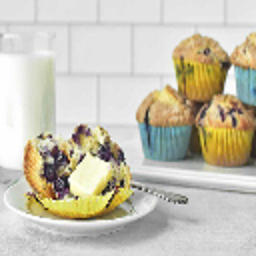

In [5]:
from IPython.display import display
from PIL import Image
import numpy as np

x = x_test[0]
x = x.reshape(128, 128, 3).astype(np.uint8)
im = Image.fromarray(x)
im = im.convert('RGB')
im = im.resize((256, 256))

display(im)

## 3. Model training

SVM + GridSearch is used.
The result contains the best model and metrics on the test set.

In [ ]:
# Amount of data for training.
# Use function load_split_parallel without that variable for taking all data
MAX_AMOUNT = 20

x_train, y_train = load_split_parallel(DATA_TRAIN, MAX_AMOUNT)
print(f"Amount of processed train files: {len(x_train)}")

Amount of processed train files: 100


In [7]:
result = train_svm_gridsearch(
    data_train=x_train,
    labels_train=y_train,
    data_test=x_test,
    labels_test=y_test,
)

result.best_params, result.test_accuracy

Fitting 5 folds for each of 35 candidates, totalling 175 fits
[CV] END ........................svc__C=0.1, svc__gamma=auto; total time=   1.7s
[CV] END ........................svc__C=0.1, svc__gamma=auto; total time=   1.9s
[CV] END .......................svc__C=0.1, svc__gamma=scale; total time=   2.0s
[CV] END .......................svc__C=0.1, svc__gamma=scale; total time=   2.0s
[CV] END ........................svc__C=0.1, svc__gamma=auto; total time=   2.1s
[CV] END ........................svc__C=0.1, svc__gamma=auto; total time=   2.3s
[CV] END .......................svc__C=0.1, svc__gamma=scale; total time=   1.9s
[CV] END ........................svc__C=0.1, svc__gamma=auto; total time=   1.9s
[CV] END .......................svc__C=0.1, svc__gamma=scale; total time=   2.4s
[CV] END .......................svc__C=0.1, svc__gamma=scale; total time=   2.7s
[CV] END .........................svc__C=0.1, svc__gamma=0.1; total time=   2.2s
[CV] END .........................svc__C=0.1, s

({'svc__C': 10, 'svc__gamma': 'scale'}, 0.7303370786516854)

## 4. Saving the model

In [8]:
MODEL_OUT_DUMMY.parent.mkdir(exist_ok=True)
save_model(result.best_model, MODEL_OUT)
MODEL_OUT_DUMMY

PosixPath('../models/notebook_model.joblib')

## 5. Batch predict

Run the model on the test dataset and collect the results into a DataFrame

In [9]:
model = load_model(MODEL_OUT)

rows = []
for img in DATA_TEST.rglob("*.jpg"):
    x = load_single_image(img)
    pred = predict_label(model, x)
    rows.append({
        "path": str(img),
        "true": img.parent.name,
        "pred": CATEGORIES[pred],
    })

df = pd.DataFrame(rows)
df.head()

,path,true,pred
0,../data/test/chihuahua/img_0_203.jpg,chihuahua,chihuahua
1,../data/test/chihuahua/img_0_22.jpg,chihuahua,chihuahua
2,../data/test/chihuahua/img_0_229.jpg,chihuahua,chihuahua
3,../data/test/chihuahua/img_0_235.jpg,chihuahua,chihuahua
4,../data/test/chihuahua/img_0_24.jpg,chihuahua,muffin


## 6. Accuracy and confusion matrix

In [10]:
(df.true == df.pred).mean()

np.float64(0.7303370786516854)

In [11]:
pd.crosstab(df.true, df.pred, normalize="index")

pred,chihuahua,muffin
true,,
chihuahua,0.653846,0.346154
muffin,0.162162,0.837838


## 7. Error inspection

Interactive slider for viewing incorrectly classified images

In [21]:
from ipywidgets import interact
from PIL import Image

errors = df[df.true != df.pred].reset_index(drop=True)
len(errors)

48

In [22]:
from IPython.display import display
from PIL import Image

MAX_HEIGHT = 300  # пиксели

@interact(i=(0, len(errors)-1))
def show_error(i):
    row = errors.iloc[i]
    img = Image.open(row.path)
    
    # сохраняем пропорции, ограничиваем высоту
    w, h = img.size
    new_w = int(w * MAX_HEIGHT / h)
    img = img.resize((new_w, MAX_HEIGHT))
    
    display(img)
    print("true:", row.true)
    print("pred:", row.pred)

interactive(children=(IntSlider(value=23, description='i', max=47), Output()), _dom_classes=('widget-interact'…

## 8. Single image prediction

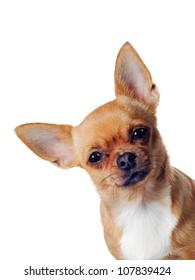

'chihuahua'

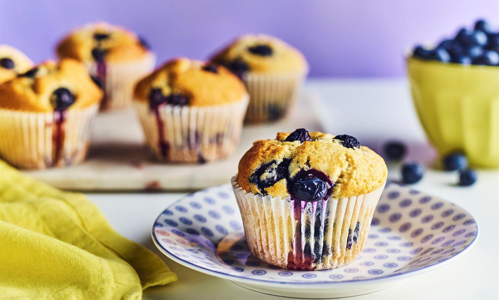

'muffin'

In [20]:
from IPython.display import display

MAX_HEIGHT = 300  # пиксели


for path in [str(DATA_TEST) + "/chihuahua/img_0_580.jpg", str(DATA_TEST) + "/muffin/img_0_602.jpg"]:
    img_path = Path(path)
    img = Image.open(img_path)
    
    w, h = img.size
    if h > MAX_HEIGHT:
        new_w = int(w * MAX_HEIGHT / h)
        img = img.resize((new_w, MAX_HEIGHT))
    
    display(img)
    x = load_single_image(img_path)
    pred = predict_label(model, x)
    display(CATEGORIES[pred])